# Determination of realistic parameters


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Determination of Heat Exhanger parameters 
c_water = 4.18e3 
U = 4000  # Overall heat transfer coefficient [W/m2K] obtained via site https://www.engineeringtoolbox.com/heat-transfer-coefficients-exchangers-d_450.html

# Qdot = U * As * F * delta_T_mean
# For tapwater heater
Th_in = 65
Th_out = 35
Tc_in = 10
Tc_out = 60
Qdot = 31e3 # W
F = 0.95

delta1 = Th_in - Tc_out
delta2 = Th_out - Tc_in

if delta1 == delta2: 
    dTmean = delta1
else:
    dTmean = (delta1 - delta2) / \
                np.log(delta1/delta2)

UAs = Qdot / (dTmean * F)
print(f'Tapwater: UAs = {UAs} W/K, U = 4000 W/m2K => As = {UAs/4000} m2')
print(f'dTlm = {dTmean} K')

# Higher UAs needed for tapwater requires less flow for the space heating system. 
# But now the problem is that the 

Tapwater: UAs = 2625.925015024058 W/K, U = 4000 W/m2K => As = 0.6564812537560145 m2
dTlm = 12.426698691192238 K


In [4]:
# lets assume that we want a 50 K temperature difference on the secundary side. And we scale the amount of water to the max water. And we request 20 kW
# Q_demand = 50 * 4.18e3 * mflow = 31 kW
mflow_cold = 31/(50*4.18)
mflow_hot = 31/(30*4.18)
print(f'mflow_cold = {mflow_cold} kg/s, mflow_hot = {mflow_hot} kg/s')

mflow_cold*3600

mflow_cold = 0.14832535885167464 kg/s, mflow_hot = 0.24720893141945774 kg/s


533.9712918660287

In [8]:
def NTU_method(mflow_h,mflow_c,Th_in,Tc_in):
 
    F = 0.95

    # Heat capacity rates
    Cc = mflow_c * c_water
    Ch = mflow_h * c_water         

    Cmin = min(Cc, Ch)
    Cmax = max(Cc, Ch)
    Cr = Cmin / Cmax

    NTU = (UAs) / Cmin

    # Effectiveness calculation for counterflow heat exchanger
    if Cr != 1:
        epsilon = (1 - np.exp(-NTU * (1 - Cr))) / (1 - Cr * np.exp(-NTU * (1 - Cr)))
    else:
        epsilon = NTU / (1 + NTU)

    Q = epsilon * Cmin * (Th_in - Tc_in)
    # print(Q)

    Tc_out = Tc_in + Q / Cc
    Th_out = Th_in - Q / Ch
    
    return Tc_out, Th_out

mflowh_in = np.linspace(0.01,2,100)
mflow_c = 0.15 # kg/s
Th_in = 65
Tc_in = 10

Tc_out_array = []
Th_out_array = []   
for mflowh in mflowh_in:
    Tc_out, Th_out = NTU_method(mflowh, mflow_c, Th_in, Tc_in)
    Tc_out_array.append(Tc_out)
    Th_out_array.append(Th_out)

plt.plot(mflowh_in, Tc_out_array, label='Tc_out')
plt.plot(mflowh_in, Th_out_array, label='Th_out')
plt.xlabel('Primairy side mass flow [kg/s]')
plt.ylabel('Outlet Temperature [C]')
plt.title('Heat Exchanger Outlet Temperatures vs Primary Side mass flow')
plt.legend()
plt.show()

NameError: name 'c_water' is not defined

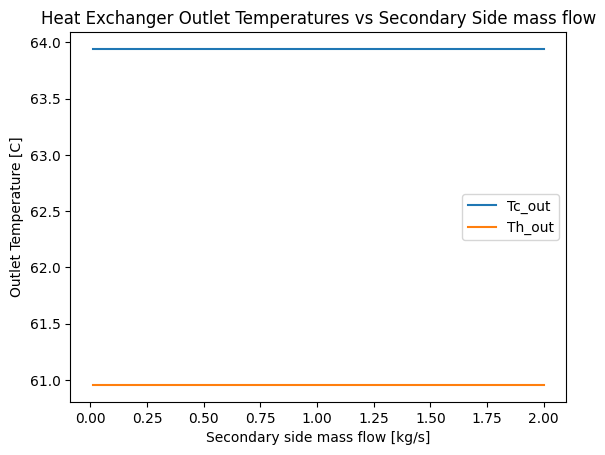

In [6]:
mflowc_in = np.linspace(0.01,2,100)
mflow_h = 0.15 # kg/s
Th_in = 65
Tc_in = 10

Tc_out_array = []
Th_out_array = []   
for mflowc in mflowc_in:
    Tc_out, Th_out = NTU_method(mflowh, mflow_c, Th_in, Tc_in)
    Tc_out_array.append(Tc_out)
    Th_out_array.append(Th_out)

plt.plot(mflowc_in, Tc_out_array, label='Tc_out')
plt.plot(mflowc_in, Th_out_array, label='Th_out')
plt.xlabel('Secondary side mass flow [kg/s]')
plt.ylabel('Outlet Temperature [C]')
plt.title('Heat Exchanger Outlet Temperatures vs Secondary Side mass flow')
plt.legend()
plt.show()

In [ ]:
mflow_h = 0.249
mflow_c = 0.15
Th_in = 65 
Tc_in = 10

Tc_out, Th_out = NTU_method(mflow_h,mflow_c, Th_in, Tc_in)
print(f'Tc_out = {Tc_out}, Th_out = {Th_out}')

# Heat demand profile
Alleen maar tap water in zomer!!

Op site Eneco staat 6.6 GJ voor warm tapwater gemiddeld per jaar voor een huishouden.

6.6e9/365 = 18 MJ per dag\
18e6/30e3 = 600 sec kan je op max vermogen douchen. 

Gaan voor een stapsgewijze opbouw alsof iemand aan het douchen is.\
Dus doen 3 min op 10 kW, 3 min op 15 kW en 4 min op 20 kW.



In [ ]:
0.067*60

In [ ]:
# Tijdas
t = np.linspace(0, 24*3600, 24*3600)

# Stapintervallen
t1_start, t1_end = 8*3600, 8.05*3600 # 3 min
t2_start, t2_end = t1_end, 8.1*3600 # 3 min
t3_start, t3_end = t2_end, 8.1667*3600 # 4 min 

# Signaal (overal nul)
y = np.zeros_like(t)

# Drie blockgolven naast elkaar
y[(t >= t1_start) & (t < t1_end)] = 10
y[(t >= t2_start) & (t < t2_end)] = 15
y[(t >= t3_start) & (t < t3_end)] = 20


plt.plot(t, y)
plt.title(f"Heat demand profile 1 appartement, total = {round(np.trapz(y, t)/1e3,3)} MJ")
plt.xlabel("Time (hours)")
plt.ylabel("Heat Demand (kW)")

ax = plt.gca()
ax.set_xlim(0, 24 * 3600)  # limits in seconds
ticks_seconds = np.arange(0, 25, 4) * 3600
ax.set_xticks(ticks_seconds)
ax.set_xticklabels([f'{int(h)}' for h in np.arange(0, 25, 4)])

plt.grid()
plt.show()

# Total heat demand profile

In [ ]:
def gaussian(x, mu, sigma):
    return (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Consumer distrubtion, only x-axis matters.
sigma_time = 1/20 # h
mu = 0
consumers = np.linspace(-2*sigma_time, 2*sigma_time, 23)
consumers_measure = gaussian(consumers, mu, sigma_time)

# Look at every minute how many consumers are consuming
total_time = 4 #h
seconds = np.linspace(-total_time//2,total_time//2,total_time*3600+1) # scale with -50 to 50 minutes
consumer_min = np.zeros_like(seconds)

for consumer in consumers:
    idx = int(consumer) + len(seconds)//2 - 1
    consumer_min[idx] += 1

# To look at the actual distribution
min_time = np.linspace(-total_min//2,total_min//2,1000)
gaus_plot = gaussian(min_time, mu, sigma_time)

Q_d_tot = np.zeros_like(minutes)

for start_time,number in enumerate(consumer_min):

    start_time = start_time - total_min//2
                
    t1_start, t1_end = start_time, (start_time + 5)
    t2_start, t2_end = t1_end, (t1_end + 3)
    t3_start, t3_end = t2_end, (t2_end + 3)

    # Heat demand height
    h1,h2,h3 = 15e3, 20e3, 25e3

    Q_d = np.zeros_like(minutes)

    # Drie blockgolven naast elkaar
    Q_d[(minutes >= t1_start) & (minutes < t1_end)] = h1*number
    Q_d[(minutes >= t2_start) & (minutes < t2_end)] = h2*number
    Q_d[(minutes >= t3_start) & (minutes < t3_end)] = h3*number

    Q_d_tot += Q_d

# plt.figure()
# plt.plot(minutes, Q_d_tot)
# plt.title(f'Total heat demand profile, std = {sigma_time} minutes')
# plt.xlabel('Time (minutes)')
# plt.ylabel('Heat Demand (W)')
# plt.show()

plt.figure()
plt.plot(min_time, gaus_plot , label = 'sigma_time')
plt.plot(consumers, consumers_measure, marker='o', linestyle='None')
plt.title('Gaussian distribution of consumer start time')
plt.xlabel('Time (minutes)')
plt.legend()
plt.show()

plt.figure()
plt.bar(minutes,consumer_min)
plt.title('Number of consumers consuming at each minute')
plt.xlabel('Time (minutes)')
plt.ylabel('Number of consumers')
plt.show()

Create four different heat demand profiles to simulate the behavior of the network.
1. ~~std = 0.3 min, all consumers start consuming at the same time.~~
2. ~~std = 1 min, 1,5,11,5,1~~
3. ~~std = 3 min, 1,1,2,2,2,2,3,2,2,2,2,1,1~~
4. ~~std = 8 min, all 1 and sometimes also an empty minute inbetween~~
5. ~~std = 70 min, all are seperate every consumer consumes seperate. (for shower of 11 minutes)~~

I left the method to determine it using std as it was not using anything from the guassian, just how big the interval of the standard deviatio was. Now I just create four profiles in which the consumers are simply 5 minutes apart. It depends on whether it creates some difference for the optimilisation. 

1. all at the same time
2. 5,13,5
3. 1,2,4,9,4,2,1
4. 1,1,2,2,2,2,3,2,2,2,2,1,1

# Pressure relation HEX

In [13]:
# 31 kW = c_p * Qprim * dT_prim_tap, dT_prim_tap = 65 -> 35 degrees
# dp_hex = rho * Kp_dp * mflow ** 2
mflow_prim = 31e3 / (4.18e3 * 30)
dp_hex = 10e3 # Pa according to brochure (looked at the value for the secondary system as there are no valves on that side. The primary system has valves, but the pressure drop is not given for that side, so I assume it is the same as the secondary side)
rho = 1000

Kp_dp = dp_hex / (rho * mflow_prim **2)

print(f'Kp_dp {Kp_dp}, mflow {mflow_prim}')

Kp_dp 163.63329864724244, mflow 0.24720893141945774


# Pressure pipe with data Rutger
Checking implementation of Darcy Weisbach

# Equal percentage valve

~~Robbert said that open Kv is 0.1, which I probably assume to be [$m^{3}/h/\sqrt{bar}$]. Which would mean that Kvs 0.1/3.6 = 0.028 [$kg/s/\sqrt{bar}$] \
And Kv0 = 0.028/50 = 5.5e-5\
However, the value of Kv0 is larger than the actual leak. But this requires the implementation of a more precise relation for h around the small area of the valve.~~

I adjusted the values of the Kv to the values obtained from fitting Rutgers data to the network. With a pump of 60kPa, not 50kPa as it wasn't strong enough to provide the requested water flow. Also with a Re = 10e3. Changing the Re effects the pressure change a lot over the pipe lines meaning they also influence the seize of the Kv. As for the upperbranch the amount of water that was flowing through is 0.1748 kg/s = 629 kg/h. A perfectly functioning heat exchanger has a mass flow of 0.24 kg/s = 864 kg/h (based on the values given in the brochure). For the valve on the first level the mass flow is: 0.02717314 kg/s = 97 kg/h. Therefore I also didn't want this to be the Kv0. So I scaled it to a seize where the valve is h= 0.2ish.

These are the calculated Kv values for fitting Rutger's data. Out of simplicity I choose Kvs = 0.003 in this way the lowest values are still in a somewhat controllable range and it indicitates that the valve is not completely open. 

Calculated Kv values for valves: [0.00011312 0.00011714 0.00012139 0.00012587 0.00013061 0.00086279
 0.0001231  0.00013042 0.00013838 0.00014707 0.00015658 0.00016703
 0.0001786  0.00019149 0.00020603 0.00022267 0.00024216 0.00026573
 0.00029559 0.00025407 0.00042842 0.00057599 0.00291382]

$\Delta p = (\frac{\dot{V}}{K_v})^2  \frac{\rho}{\rho_{\textbf{ref}}} = (\frac{\dot{m}}{\rho K_v})^2$, page 25 phd, but in the simulation I just do: $(\frac{\dot{m}}{K_v})^2$

Valve authority should be between 0.3 - 0.5. page 114

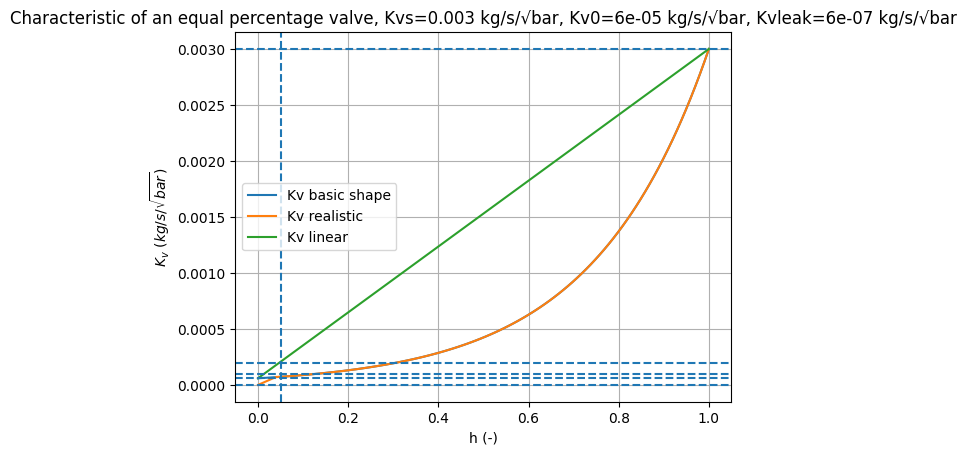

In [3]:
# functions return Kv/Kvs

def Kv_ideal_func(h, Kvs):
    Kv0 = Kvs/50
    return (Kvs / Kv0) ** (h-1) * Kvs

def Kvleak_func(h,Kvs):
    Kvleak = Kvs/5000
    return (Kvs/Kvleak) ** (h-1)*Kvleak

def Kv_real_func(h,Kvs,h_star):
    Kv0 = Kvs/50
    Kvleak = Kvs/5000

    if h < h_star:
        Kv = Kvleak + h*(Kv_ideal_func(0.1,Kvs) - Kvleak)/h_star
        # Kv = Kvleak_func(h, Kvs/100)
    else:
        Kv = (Kvs/Kv0) ** (h-1)* Kvs
    return Kv

def linear_valve_func(h, Kvs):
    Kv0 = Kvs/50
    return h * (Kvs - Kv0) + Kv0

h_array = np.linspace(0,1,100)
Kvs = 0.003
h_star = 0.05


Kv_ideal_array = []
Kv_real_array = []
Kv_linear_array = []
for h in h_array:
    Kv_ideal_array.append(Kv_ideal_func(h,Kvs))
    Kv_real_array.append(Kv_real_func(h,Kvs,h_star))
    Kv_linear_array.append(linear_valve_func(h, Kvs))

# In phd thesis he says that the typical ratio between Kvs/Kv0 is between 25 - 50 (p26) Higher ratio means beter control flow. 

plt.figure()

plt.plot(h_array, Kv_ideal_array, label='Kv basic shape')
plt.plot(h_array, Kv_real_array, label='Kv realistic')
plt.plot(h_array, Kv_linear_array, label='Kv linear')
plt.axhline(Kvs/5000, linestyle='--')
plt.axhline(Kvs/50, linestyle='--')
plt.axhline(Kvs, linestyle='--')
plt.axhline(0.0001, linestyle='--')
plt.axhline(0.0002, linestyle='--')


plt.axvline(h_star, linestyle='--')

plt.xlabel('h (-)')
plt.ylabel(r'$K_v$ $(kg/s/\sqrt{bar}$)')
plt.title(f"Characteristic of an equal percentage valve, Kvs={Kvs} kg/s/√bar, Kv0={Kvs/50} kg/s/√bar, Kvleak={Kvs/5000} kg/s/√bar")

plt.legend()
plt.grid()
plt.show()


## Linear valve

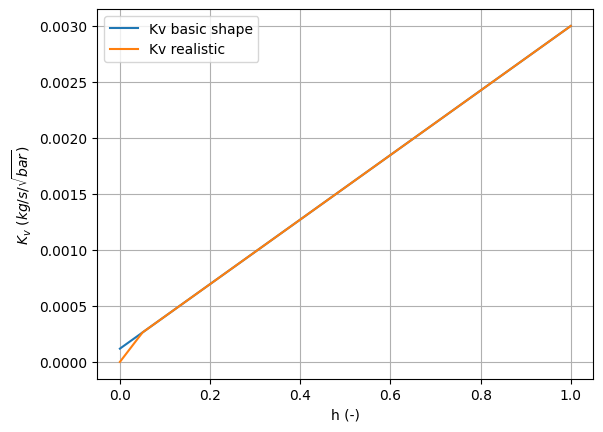

In [15]:
def Kv_linear_ideal(h, Kvs):
    Kv0 = Kvs/25
    return Kv0 + h*(Kvs-Kv0)

def Kv_linear_real(h, Kvs, h_star):
    Kv0 = Kvs/25
    Kvleak = Kvs/2000

    if h < h_star:
        return Kvleak + h*(Kv_linear_ideal(h_star,Kvs) - Kvleak)/h_star
    else:
        return Kv0 + h*(Kvs-Kv0)


Kv_linear_ideal_array = []
Kv_linear_real_array = []

h_array = np.linspace(0,1,100)
Kvs = 0.003
h_star = 0.05

for h in h_array:
    Kv_linear_ideal_array.append(Kv_linear_ideal(h,Kvs))
    Kv_linear_real_array.append(Kv_linear_real(h,Kvs,h_star))

plt.figure()

plt.plot(h_array, Kv_linear_ideal_array, label='Kv basic shape')
plt.plot(h_array, Kv_linear_real_array, label='Kv realistic')
plt.ylabel(r'$K_v$ $(kg/s/\sqrt{bar}$)')
plt.xlabel('h (-)')

plt.grid()
plt.legend()
plt.show()

In [ ]:
num_steps_band = 30  # Define number of discrete steps
T_set_overflow = 55
P_band = 3
h_band = np.zeros(100)
node_temp_array = np.linspace(50, 60, 100)
for i, node_temp in enumerate(node_temp_array):
    if node_temp >= T_set_overflow:
        h_band[i] = 0
    elif node_temp <= T_set_overflow - P_band:
        h_band[i] = 1   
    else:
        h_band[i] = np.floor((T_set_overflow - node_temp) / P_band * num_steps_band) / num_steps_band
plt.step(node_temp_array, h_band)
plt.show()

In [ ]:
mflow = 0.24 #kg/s
# mflow = 1 * np.pi * 1000 * 0.02**2
Kvs = 0.1/3.6
h_star = 0.05

dp_array_ideal = np.zeros(100)
dp_array_real = np.zeros(100)

for k in range(len(h_array)):   
    Kv_ideal = Kv_ideal_func(h_array[k],Kvs)
    Kv_real = Kv_real_func(h_array[k],Kvs, h_star)
    dp_array_ideal[k] = (mflow/(Kv_ideal))**2
    dp_array_real[k] = (mflow/(Kv_real))**2

plt.figure()
plt.plot(h_array,dp_array_ideal)
plt.xlabel("Valve lift (-)")
plt.ylabel("Pressure drop [Pa]")
plt.title(f"Basic shape pressure drop with mflow {round(mflow,4)} kg/s")

plt.figure()
plt.plot(h_array, dp_array_real)
plt.xlabel("Valve lift (-)")
plt.ylabel("Pressure drop [Pa]")
plt.title(f"Kvleak pressure drop with mflow {round(mflow,4)} kg/s")
# plt.show()

In [ ]:
dp = 1
mflow_array_real = np.zeros(100)
mflow_array_ideal = np.zeros(100)

Kvs = 0.1/3.6
h_star = 0.05

for k in range(len(h_array)):
    
    Kv_real = Kv_real_func(h_array[k],Kvs, h_star)
    Kv_ideal = Kv_ideal_func(h_array[k], Kvs)
    mflow_array_real[k] = Kv_real * np.sqrt(dp)
    mflow_array_ideal[k] = Kv_ideal * np.sqrt(dp)

plt.plot(h_array, mflow_array_ideal, label = 'real')
plt.plot(h_array, mflow_array_ideal, label = 'ideal')
plt.legend()
plt.title(f'Constant pressure: {dp} Pa')
plt.xlabel('h (-)')
plt.ylabel('Mass flow (kg/s)')


Lets say that you want to reach the average flow of 140 L/h for the setpoint of 55 degrees. If you use the linear valve (with already the Kv0 increase as it is now divided by 25 and also h_star = 0.02) the following amount of pressure do you need to constantly provide to produce a 140/3600 kg/s.


In [18]:
mflow = 140/3600 # kg/s
h1 = 0.033
h2 = 0.15
h3 = 0.20
h4 = 0.25

Kvs = 0.000587 
h_star = 0.02
pressure = 40e3

print(f'Pressure drop over only the bypass valve, but this is not feasible as during periods of high demand pressure drop over the pipes increase significantly.' + '\n'
'Also the overflow almost never comes with a h displacement above 0.2')
print(f' h = {h1}, with dp = {np.round((mflow/Kv_linear_real(h1, Kvs, h_star))**2)/1e3} kPa, with {pressure} kPa this is the mass flow: {np.round(np.sqrt(pressure)*Kv_linear_real(h1, Kvs, h_star)*3600)} L/h')
print(f' h = {h2}, with dp = {np.round((mflow/Kv_linear_real(h2, Kvs, h_star))**2)/1e3} kPa, with {pressure} kPa this is the mass flow: {np.round(np.sqrt(pressure)*Kv_linear_real(h2, Kvs, h_star)*3600)} L/h')
print(f' h = {h3}, with dp = {np.round((mflow/Kv_linear_real(h3, Kvs, h_star))**2)/1e3} kPa, with {pressure} kPa this is the mass flow: {np.round(np.sqrt(pressure)*Kv_linear_real(h3, Kvs, h_star)*3600)} L/h')
print(f' h = {h4}, with dp = {np.round((mflow/Kv_linear_real(h4, Kvs, h_star))**2)/1e3} kPa, with {pressure} kPa this is the mass flow: {np.round(np.sqrt(pressure)*Kv_linear_real(h4, Kvs, h_star)*3600)} L/h')

Pressure drop over only the bypass valve, but this is not feasible as during periods of high demand pressure drop over the pipes increase significantly.
Also the overflow almost never comes with a h displacement above 0.2
 h = 0.033, with dp = 854.238 kPa, with 40000.0 kPa this is the mass flow: 30.0 L/h
 h = 0.15, with dp = 129.64 kPa, with 40000.0 kPa this is the mass flow: 78.0 L/h
 h = 0.2, with dp = 81.545 kPa, with 40000.0 kPa this is the mass flow: 98.0 L/h
 h = 0.25, with dp = 55.983 kPa, with 40000.0 kPa this is the mass flow: 118.0 L/h


# Pump 

v_max = 1.5 m/s \
mdot = pi * 0.02 ** 2 * 1 * 1000 = 0.6 pi 


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[-2.57999715e-03 -6.50453103e-01  6.09976599e+04]


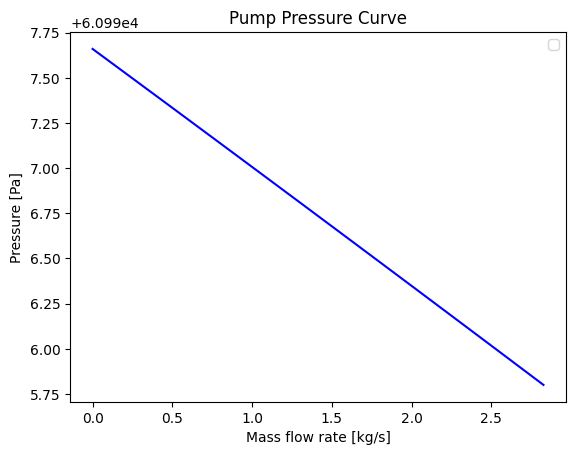

60997.65992345956
60996.4246813664


In [ ]:
# Measurement data points
mflow_max = 0.02**2 * 1.5 * 1000 * np.pi  # kg/s
dp_data = np.array([61e3, 60e3, 57e3, 52e3, 48e3, 40e3])  # Pa
mflow_data = np.array([0, 200, 400, 600, 800, 970])/0.36  # kg/s

# Fit quadratic curve to data: dp = a*mflow^2 + b*mflow + c
coefficients = np.polyfit(mflow_data, dp_data, 2)
a, b, c = coefficients

print(coefficients)

# Update pump_curve function with fitted coefficients
def pump_curve(a,b,c,mflow):
    dp = a * mflow**2 + b * mflow + c
    return dp

# Verify fit
mflow_test = np.linspace(0, 1.5*mflow_max, 50)
dp_fit_current = [pump_curve(a,b,c,m) for m in mflow_test]

plt.figure()
# plt.plot(mflow_data, dp_data, 'ro', label='Measurement data')
plt.plot(mflow_test, dp_fit_current, 'b-')
plt.xlabel('Mass flow rate [kg/s]')
plt.ylabel('Pressure [Pa]')
plt.title('Pump Pressure Curve')
plt.legend()
plt.show()
print(pump_curve(a,b,c,0))
print(pump_curve(a,b,c,mflow_max))

Check for 50kPa pump as it is used in simulation:

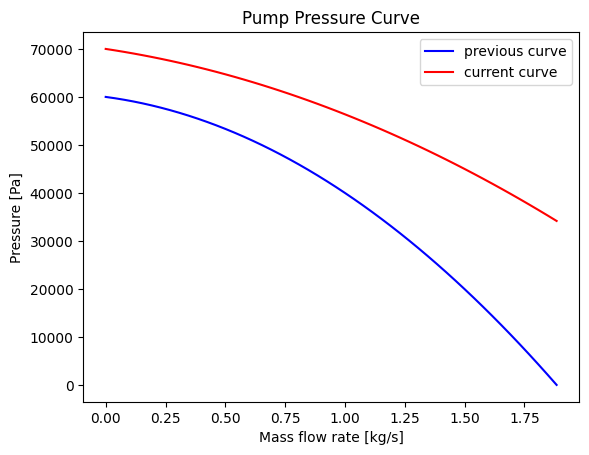

In [18]:
a_prev = -13369.01955677
b_prev = -6630.98044323    
c_prev = 60000.0
# Verify fit
mflow_test = np.linspace(0, mflow_max, 50)
dp_fit_prev = [pump_curve(a_prev, b_prev, c_prev, m) for m in mflow_test]

plt.figure()
# plt.plot(mflow_data, dp_data, 'ro', label='Measurement data')
plt.plot(mflow_test, dp_fit_prev, 'b-', label = 'previous curve')
plt.plot(mflow_test, dp_fit_current, 'r-', label = 'current curve')
plt.xlabel('Mass flow rate [kg/s]')
plt.ylabel('Pressure [Pa]')
plt.title('Pump Pressure Curve')
plt.legend()
plt.show()

# pump_curve()

# Compare Rutgers data with simulation, checking pressure loss over pipes

### Checking Darcy Weisbach 

In [4]:
# Determination of the Reynolds number based on the Darcy-Weisbach equation
L  = 3  # m
D = 0.04 # m
v = 0.87 # m/s
dp = 803.5  # Pa

rho = 1000 # kg/m3
epsilon = 0.045e-3 # m

# Re = rho * v * D / mu
mu = 0.001 # Pa.s
Re_check = rho * v * D / mu
f_check = (1 / (-1.8 * np.log10( ((epsilon/D)/3.7)**1.11 + 6.9/Re_check)))**2
dp = f_check * L * rho * v**2 / (2 * D)
print(f'f_check = {f_check}, Re check = {Re_check}, dp check = {dp} Pa')

# Solve Haaland equation for Re
f = (2 * dp * D) / (L * rho * v**2)
e_term = (epsilon/D/3.7)**1.11
Re = 6.9 / (10**(-1/(1.8*np.sqrt(f))) - e_term)

print(f' f = {f}, dp = {dp} Pa, Re = {Re}, epsilon/D = {epsilon/D}')

f_check = 0.02532897889417203, Re check = 34800.0, dp check = 718.9314046874554 Pa
 f = 0.025328978894172027, dp = 718.9314046874554 Pa, Re = 34799.99999999992, epsilon/D = 0.0011250000000000001


# Check for change in velocity and effect on f
clear difference when it is not turbulent. But introducing this might nonlinearities in the simulatio due to the switching between flow regimes. Or solving the Hoolebrook equation but that would not fit in the simulation.

In [8]:
def compare_f(v,D):
    # Re = rho * v * D / mu
    mu = 0.5465e-3 # Pa.s for 50 degrees
    rho = 1000

    # v = mflow / (rho * np.pi * (D/2)**2)
    Re = rho * v * D / mu

    if Re > 4000:
        epsilon = 0.045e-3
        log_term = ((epsilon/D)/3.7)**1.11 + (6.9/Re)
        f = (1 / (-1.8 * np.log10(log_term)))**2
    else:
        f = 64/Re 
    
    print(f'Re {Re}, f {f}, v {v}')

v = [0.047, 0.1, 0.2, 0.5, 0.8, 1, 1.5]
D = 0.04

for velocity in v:
    compare_f(velocity, D)

Re 3440.073193046661, f 0.018604255319148933, v 0.047
Re 7319.304666056724, f 0.03495116316294495, v 0.1
Re 14638.609332113449, f 0.029681421424448524, v 0.2
Re 36596.52333028362, f 0.025137254281048536, v 0.5
Re 58554.437328453794, f 0.02361629404072268, v 0.8
Re 73193.04666056724, f 0.02304692205434802, v 1
Re 109789.56999085087, f 0.022222582049795957, v 1.5


#### Difference in turbulent and laminair flow

In [6]:
def dp_tur(L,D,mflow):

    # Re = rho * v * D / mu
    mu = 0.001 # Pa.s for 50 degrees
    epsilon = 0.045e-3
    rho = 1000

    v = mflow / (rho * np.pi * (D/2)**2)
    Re = rho * v * D / mu

    # Re = 10e3

    # print(f'Re {Re}, v {v}')
# 
    log_term = ((epsilon/D)/3.7)**1.11 + (6.9/Re)
    f = (1 / (-1.8 * np.log10(log_term)))**2

    return f * (L / D) * (rho * v**2 / 2)

def dp_lam(L,D,mflow):

    # Re = rho * v * D / mu
    mu = 0.001 # Pa.s for 50 degrees
    rho = 1000

    v = mflow / (rho * np.pi * (D/2)**2)
    Re = rho * v * D / mu

    f = 64/Re
    # print(f)

    return f * (L / D) * (rho * v**2 / 2)

#### Validating the found velocities in a pressure loop

In [3]:
# velocities
vgem1 = 0.8738
vgem2 = 0.8522113
v_hex = vgem1 - vgem2

# Pipe diameters
D = 0.04
D_hex_pipes = 0.02

mflow1 = np.pi * (D/2) **2 * vgem1 * rho
mflow_hex = np.pi * (D/2) ** 2 * v_hex * rho

# Hex pressure calc
Kp_dp = 611
dp_hex = Kp_dp * 1000 * mflow_hex ** 2

dp_meas = 803
m_hex_loop =  dp_tur(3,D_hex_pipes,mflow_hex)
return_pump = dp_tur(3,D,vgem1*np.pi*rho*(D/2)**2)


dp_tot = (dp_hex +  # pressure drop over HEX, where the pipes connected to the nodes are not taken into account
            dp_meas + # measured pressure drop over first pipe of 3 m
            m_hex_loop + # pressure dorp over 3m of DN40 conencted to the HEX loop
            return_pump) # pressure drop over pipe line connected to return network and the pump pipe.

print(f'{dp_tot}: total dp ')
print(f'{dp_hex}: hex dp')
print(f'{m_hex_loop}: 3m hex loop ')
print(f'{return_pump}: 2 m return + pump pipe')
print(f' \n')
print(f'{mflow_hex} mflow_hex ')
print(f'{mflow1} mflow vgem1')

# stel dat de hex flow geleverd is in 1 minuut, terwijl het gemiddlede van een uur is
mflow_hex_1min = mflow_hex*60
# Tc_out, Th_out = NTU_method(mflow_hex_1min) # Th_in = 65, Tc_in = 10
# print(f'Tc_out = {Tc_out}, Th_out = {Th_out}')

NameError: name 'rho' is not defined

###  Druk verval leidingen Rutger
Aanname van Rutger van 5kPa klopt niet. Het is veel meer druk verlies.

In [4]:
import os
import pandas as pd

def dp_fric(L,D,v,Re):
    f = (1 / (-1.8 * np.log10( ((epsilon/D)/3.7)**1.11 + 6.9/Re)))**2
    # print(f)
    return f * (L / D) * (rho * v**2 / 2), f

cwd = os.getcwd()
average_v_file = os.path.join(cwd, 'data', 'data_23floors_Rutger.csv')
average_v = pd.read_csv(average_v_file)['average v'].values

dp_tot = 0
for i in range(23):
    if i<6:
        D = 0.04
    elif 6<= i <19:
        D = 0.032
    else:
        D = 0.025
    v = average_v[i]
    mflow = v * np.pi * (D/2)**2 * 1000
    dp_pipe, f = dp_fric(3,D,v, 10e3)
    print(f'mflow {mflow}, dp_pipe {dp_pipe} Pa, friction factor {f}, velocity {v} m/s, diameter {D} m')

    dp_tot += dp_pipe

print(f'Reynolds {Re}')

# print(f'{dp_tot} Pa total pressure drop over 23 pipes, and only for going up')

NameError: name 'epsilon' is not defined

In [ ]:
mflow_test = 0.33 #kg/s
L_test = 3
D_test = 0.04
v_test = mflow_test / (1000 * np.pi * (D_test/2)**2)
dp, f = dp_fric(L_test,D_test,v_test,10e3)
dp

# Supply temperature as control variable

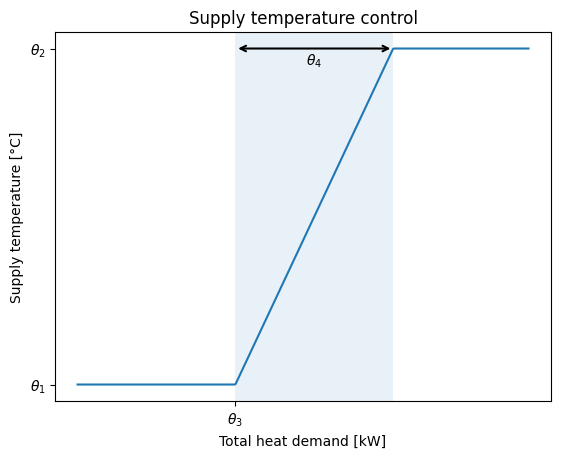

In [21]:
# X-axis
x = np.linspace(0, 200, 500)  # total heat demand [W]

# Supply temperature profile (decreasing)
T_sup = np.zeros_like(x)

T_sup_min = 60 # theta1
T_sup_max = 65 # theta2
P_band = 70 # theta3
P_band_end = 140 # theta4

for i, xi in enumerate(x):
    if xi < P_band_end - P_band:
        T_sup[i] = T_sup_min          # constant region
    elif xi <= P_band_end:
        T_sup[i] = T_sup_min + (xi - P_band_end + P_band) * (T_sup_max - T_sup_min) / (P_band)  # linear P-band
    else:
        T_sup[i] = T_sup_max          # saturated region

# Plot
plt.figure()
plt.plot(x, T_sup)

plt.xlabel("Total heat demand [kW]")
plt.ylabel("Supply temperature [°C]")
plt.title("Supply temperature control")
# Draw double arrow for P-band
plt.annotate(
    '', 
    xy=(P_band_end, T_sup_max),      # right end of P-band
    xytext=(P_band_end - P_band, T_sup_max),  # left end of P-band
    arrowprops=dict(arrowstyle='<->', linewidth=1.5)
)

# Label the P-band
plt.text((P_band_end - P_band + P_band_end) / 2, T_sup_max - 0.25, r'$\theta_4$', ha='center')

ax = plt.gca()
# ax.axhline(55, linestyle='--', linewidth=1.5)
# ax.text(
#     ax.get_xlim()[0], 55,
#     r' $T_{set}$',
#     va='center',
#     ha='left'
# )
# Y-axis thetas
plt.yticks([T_sup_min, T_sup_max], [r"$\theta_1$", r"$\theta_2$"])
# X-axis thetas
plt.xticks([P_band_end - P_band], [r"$\theta_3$"])
plt.axvspan(P_band_end - P_band, P_band_end, alpha=0.1)
plt.show()

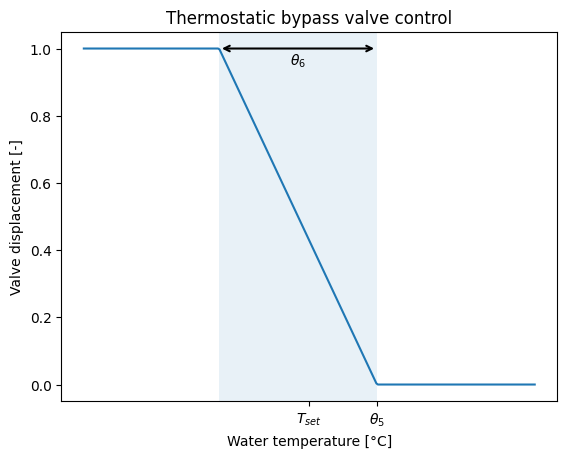

In [2]:
# X-axis
x = np.linspace(50, 60, 300)

# Supply temperature profile (decreasing)
h_valve = np.zeros_like(x)

P_band_start = 53
P_band_end = 56.5

for i, xi in enumerate(x):
    if xi < P_band_start:
        h_valve[i] = 1   # high constant region (θ2)
    elif xi <= P_band_end:
        h_valve[i] = 1 - (xi - P_band_start) / (P_band_end - P_band_start)  # linear decrease
    else:
        h_valve[i] = 0   # low constant region (θ1)

# Plot
plt.figure()
plt.plot(x, h_valve)

plt.xlabel("Water temperature [°C]")
plt.ylabel("Valve displacement [-]")
plt.title("Thermostatic bypass valve control")

# Draw double arrow for P-band
plt.annotate(
    '', 
    xy=(P_band_end, 1.0),      # right end of P-band
    xytext=(P_band_start, 1.0),  # left end of P-band
    arrowprops=dict(arrowstyle='<->', linewidth=1.5)
)

# Label the P-band
plt.text((P_band_start + P_band_end) / 2, 0.95, r'$\theta_6$', ha='center')

# X-axis thetas
plt.xticks([55,P_band_end], [r"$T_{set}$", r"$\theta_5$"])
plt.axvspan(P_band_start, P_band_end, alpha=0.1)
plt.show()

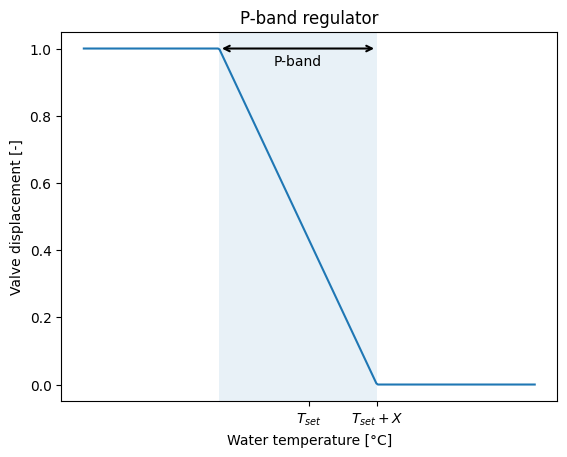

In [3]:
# X-axis
x = np.linspace(50, 60, 300)

# Supply temperature profile (decreasing)
h_valve = np.zeros_like(x)

P_band_start = 53
P_band_end = 56.5

for i, xi in enumerate(x):
    if xi < P_band_start:
        h_valve[i] = 1   # high constant region (θ2)
    elif xi <= P_band_end:
        h_valve[i] = 1 - (xi - P_band_start) / (P_band_end - P_band_start)  # linear decrease
    else:
        h_valve[i] = 0   # low constant region (θ1)

# Plot
plt.figure()
plt.plot(x, h_valve)

plt.xlabel("Water temperature [°C]")
plt.ylabel("Valve displacement [-]")
plt.title("P-band regulator")

# Draw double arrow for P-band
plt.annotate(
    '', 
    xy=(P_band_end, 1.0),      # right end of P-band
    xytext=(P_band_start, 1.0),  # left end of P-band
    arrowprops=dict(arrowstyle='<->', linewidth=1.5)
)

# Label the P-band
plt.text((P_band_start + P_band_end) / 2, 0.95, 'P-band', ha='center')

# X-axis thetas
plt.xticks([55,P_band_end], [r"$T_{set}$", r"$T_{set} + X$"])
plt.axvspan(P_band_start, P_band_end, alpha=0.1)
plt.show()